In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [2]:
data = pd.read_csv(r'C:\Users\Виталий\PycharmProjects\MLZoomcamp2026\car_fuel_efficiency_2026.csv')
data = data[['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year', 'fuel_efficiency_mpg']]
data.head()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,2180,243.0,3870,2006,31.9
1,2390,272.0,4210,2008,31.3
2,2320,267.0,4240,1996,27.5
3,2130,258.0,4490,1989,28.5
4,2580,304.0,4510,1994,31.0


### EDA

<Axes: xlabel='fuel_efficiency_mpg', ylabel='Count'>

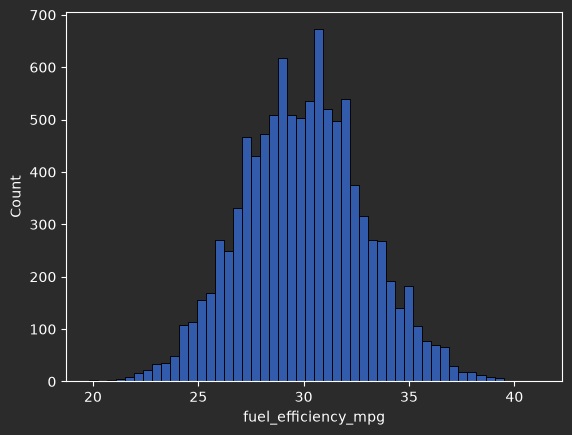

In [3]:
sns.histplot(data['fuel_efficiency_mpg'], bins=50)

## Question 1

In [4]:
col_with_miss = data.columns[data.isnull().any()].to_list()
print(f'Columns with missing values:\n{col_with_miss[0]}')

Columns with missing values:
horsepower


## Question 2

In [5]:
median_fill_horsepower = data['horsepower'].median()
print(f'Median fill horsepower:\n{median_fill_horsepower}')

Median fill horsepower:
254.0


### Prepare and split the dataset

In [6]:
n = len(data)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

np.random.seed(42)
idx = np.arange(n)
np.random.shuffle(idx)

df_train = data.iloc[idx[:n_train]].reset_index(drop=True)
df_val = data.iloc[idx[n_train:n_train + n_val]].reset_index(drop=True)
df_test = data.iloc[idx[n_train + n_val:]].reset_index(drop=True)

In [7]:
df_train.head()

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,1900,239.0,3790,2015,32.5
1,2000,224.0,4380,1992,29.1
2,2330,286.0,4090,2022,34.1
3,2300,NaN,4150,1997,30.6
4,2340,269.0,4400,2001,30.7


In [8]:
y_train = df_train.fuel_efficiency_mpg.values
y_val = df_val.fuel_efficiency_mpg.values
y_test = df_test.fuel_efficiency_mpg.values

del df_train['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

In [9]:
def linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])
    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w = XTX_inv.dot(X.T).dot(y)

    return w[0], w[1:]

In [10]:
def rmse(y, y_pred):
    error = y_pred - y
    mse = (error ** 2).mean()
    return np.sqrt(mse)

### Filling by Zero

In [11]:
df_train_zero = df_train.fillna(0)
df_val_zero = df_val.fillna(0)

In [12]:
w_0, w = linear_regression(df_train_zero, y_train)
y_pred_val = w_0 + df_val_zero.dot(w)
rmse_zero = np.round(rmse(y_val, y_pred_val), 3)
print(f'RMSE filling by Zero: {rmse_zero}')

RMSE filling by Zero: 2.205


### Filling by Mean

In [13]:
mean = df_train['horsepower'].mean()

df_train_mean = df_train.fillna(mean)
df_val_mean = df_val.fillna(mean)

In [14]:
w_0, w = linear_regression(df_train_mean, y_train)
y_pred_val = w_0 + df_val_mean.dot(w)
rmse_mean = np.round(rmse(y_val, y_pred_val), 3)
print(f'RMSE filling by MEAN: {rmse_mean}')

RMSE filling by MEAN: 2.202


In [16]:
print(f'RMSE filling by MEAN is equal RMSE filling by ZERO: {rmse_mean.__eq__(rmse_zero)}')
print(f'RMSE filling by MEAN is less than RMSE filling by ZERO: {rmse_mean < rmse_zero}')

RMSE filling by MEAN is equal RMSE filling by ZERO: False
RMSE filling by MEAN is less than RMSE filling by ZERO: True


## Question 4

In [17]:
def regularization_linear_regression(X, y, r):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])
    XTX = X.T.dot(X)
    XTX = XTX + r * np.eye(XTX.shape[0])
    XTX_inv = np.linalg.inv(XTX)
    w = XTX_inv.dot(X.T).dot(y)

    return w[0], w[1:]

In [21]:
r_list = [0, 0.01, 0.1, 1, 5, 10, 100]
for r in r_list:
    w_0, w = regularization_linear_regression(df_train_zero, y_train, r)
    y_pred_val = w_0 + df_val_zero.dot(w)

    print(r, np.round(rmse(y_val, y_pred_val),4), w_0)

0 2.2053 -153.88496188192437
0.01 2.2058 -148.3092124412991
0.1 2.2241 -111.83871039265549
1 2.3492 -32.331865964988545
5 2.4094 -7.772852209985205
10 2.4195 -3.987116416008144
100 2.4292 -0.4082196488481208


## Question 5

In [22]:
n = len(data)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

seeds_list = [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]

rmse_list = []
for seed in seeds_list:
    np.random.seed(seed)
    idx = np.arange(n)
    np.random.shuffle(idx)

    df_train = data.iloc[idx[:n_train]].reset_index(drop=True)
    df_val = data.iloc[idx[n_train:n_train + n_val]].reset_index(drop=True)
    df_test = data.iloc[idx[n_train + n_val:]].reset_index(drop=True)

    y_train = df_train.fuel_efficiency_mpg.values
    y_val = df_val.fuel_efficiency_mpg.values
    y_test = df_test.fuel_efficiency_mpg.values

    del df_train['fuel_efficiency_mpg']
    del df_val['fuel_efficiency_mpg']
    del df_test['fuel_efficiency_mpg']

    df_train_zero = df_train.fillna(0)
    df_val_zero = df_val.fillna(0)

    w_0, w = linear_regression(df_train_zero, y_train)
    y_pred_val = w_0 + df_val_zero.dot(w)
    rmse_zero = rmse(y_val, y_pred_val)
    rmse_list.append(rmse_zero)

In [23]:
print(rmse_list)
np.round(np.std(rmse_list), 3)

[np.float64(2.2392041430485716), np.float64(2.202112821083587), np.float64(2.163419778753105), np.float64(2.2043588768541773), np.float64(2.201880094336824), np.float64(2.2457851509077487), np.float64(2.269721207952116), np.float64(2.190794599936849), np.float64(2.2166112016917348), np.float64(2.2070365928200184)]


np.float64(0.029)

## Question 6

In [27]:
n = len(data)
n_val = int(n * 0.2)
n_test = int(n * 0.2)
n_train = n - n_val - n_test

idx = np.arange(n)
np.random.seed(9)
np.random.shuffle(idx)

df_train = data.iloc[idx[:n_train]]
df_val = data.iloc[idx[n_train:n_train + n_val]]
df_test = data.iloc[idx[n_train + n_val:]]

df_train = pd.concat([df_train, df_val]).reset_index(drop=True)
df_test = df_test.reset_index(drop=True)

y_train = df_train.fuel_efficiency_mpg.values
y_test = df_test.fuel_efficiency_mpg.values

del df_train['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

df_train_zero = df_train.fillna(0)
df_test_zero = df_test.fillna(0)

w_0, w = regularization_linear_regression(df_train_zero, y_train, r=0.001)
y_test_val = w_0 + df_test_zero.dot(w)

print(np.round(rmse(y_test, y_test_val), 3), w_0)

2.236 -152.37535772487973
